In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df=pd.read_csv("C:\\Users\\sitar\\DataScience-11AM-Sumit\\Projects-on-EDA\\netflix_titles.csv")

In [107]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [108]:
df.shape

(8807, 12)

In [109]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
missing_value=df.isnull().sum()
missing_value[missing_value > 0]

director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

In [113]:
len(df)

8807

In [114]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

director      29.908028
country        9.435676
cast           9.367549
date_added     0.113546
rating         0.045418
duration       0.034064
dtype: float64

In [115]:
#unique values and frequency of each value in the director column.
print(df['director'].unique)
df['director'].value_counts(dropna=False)

<bound method Series.unique of 0       Kirsten Johnson
1                   NaN
2       Julien Leclercq
3                   NaN
4                   NaN
             ...       
8802      David Fincher
8803                NaN
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: object>


director
NaN                               2634
Rajiv Chilaka                       19
Raúl Campos, Jan Suter              18
Suhas Kadav                         16
Marcus Raboy                        16
                                  ... 
Raymie Muzquiz, Stu Livingston       1
Joe Menendez                         1
Eric Bross                           1
Will Eisenberg                       1
Mozez Singh                          1
Name: count, Length: 4529, dtype: int64

In [116]:
df['director'].dtypes

dtype('O')

In [117]:
#fill the missing value in director column
df['director'].fillna('unknown',inplace=True)

C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\921807629.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('unknown',inplace=True)


In [118]:
df['director'].isna().sum()

np.int64(0)

In [119]:
df['cast'].fillna('unknown',inplace=True)

C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\2491260448.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('unknown',inplace=True)


In [120]:
df['cast'].isna().sum()

np.int64(0)

In [121]:
df['country'].dtypes

dtype('O')

In [122]:
df['country'].value_counts(dropna=False)

country
United States                             2818
India                                      972
NaN                                        831
United Kingdom                             419
Japan                                      245
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 749, dtype: int64

In [123]:
df['country'] = df['country'].fillna(method='ffill')

C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\3249587819.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['country'] = df['country'].fillna(method='ffill')


In [124]:
df['country'].isna().sum()

np.int64(0)

In [125]:
df['country'] = df['country'].str.title()

In [126]:
df['country'].value_counts(dropna=False)

country
United States                        3095
India                                1071
United Kingdom                        465
Japan                                 270
South Korea                           218
                                     ... 
United States, South Korea, Japan       1
Argentina, United States, Mexico        1
Finland, Germany, Belgium               1
Canada, Norway                          1
United Arab Emirates, Jordan            1
Name: count, Length: 748, dtype: int64

In [37]:
df['date_added'].value_counts(dropna=False)

date_added
January 1, 2020      109
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
                    ... 
December 4, 2016       1
November 21, 2016      1
November 19, 2016      1
November 17, 2016      1
January 11, 2020       1
Name: count, Length: 1768, dtype: int64

In [38]:
df['date_added'].dtype

dtype('O')

In [40]:
df['date_added'].isna().sum()

np.int64(10)

In [41]:
df['date_added'].fillna("Unknown",inplace=True)

C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\1470177133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna("Unknown",inplace=True)


In [42]:
df['date_added'].isna().sum()

np.int64(0)

In [45]:
df['date_added'] = df['date_added'].fillna(method='ffill')

C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\3385547354.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'] = df['date_added'].fillna(method='ffill')


In [50]:
# convert the object type date to date type
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [51]:
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [52]:
df['date_added'].value_counts(dropna=False)

date_added
2020-01-01    109
NaT            98
2019-11-01     89
2018-03-01     75
2019-12-31     74
             ... 
2017-04-04      1
2017-03-28      1
2017-03-07      1
2017-02-27      1
2020-01-11      1
Name: count, Length: 1700, dtype: int64

In [53]:
df['date_added'] = df['date_added'].fillna(method='ffill')

C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\3385547354.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'] = df['date_added'].fillna(method='ffill')


In [54]:
df['date_added'].value_counts(dropna=False)

date_added
2020-01-01    113
2019-11-01     96
2019-12-31     77
2018-03-01     75
2018-10-01     72
             ... 
2017-04-04      1
2017-03-28      1
2017-03-07      1
2017-02-27      1
2020-01-11      1
Name: count, Length: 1699, dtype: int64

In [55]:
df['date_added'].dtype

dtype('<M8[ns]')

In [56]:
df['date_added'].isna().sum()

np.int64(0)

In [58]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

In [59]:
df['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [60]:
df['rating'] = df['rating'].fillna("Unknown")


In [61]:
invalid_ratings = ['74 min', '84 min', '66 min']
df.loc[df['rating'].isin(invalid_ratings), 'rating'] = "Unknown"

In [62]:
df['rating'] = df['rating'].str.upper()

In [63]:
df['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
UNKNOWN        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [66]:
df['rating'].head()

0    PG-13
1    TV-MA
2    TV-MA
3    TV-MA
4    TV-MA
Name: rating, dtype: object

In [68]:
df['rating'].isna().sum()

np.int64(0)

In [69]:
# lastly clean duration column
df['duration'].isna().sum()

np.int64(3)

In [71]:
df['duration'].value_counts(dropna=False)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
             ... 
189 min         1
10 min          1
3 min           1
229 min         1
191 min         1
Name: count, Length: 221, dtype: int64

In [73]:
# Create duration_type column
df['duration_type'] = np.where(df['duration'].str.contains('Season'), 'Season', 'Minutes')

# Overwrite duration column with numeric values
df['duration'] = df['duration'].str.extract(r'(\d+)').astype(float)

print(df[['duration', 'duration_type']].head(10))


   duration duration_type
0      90.0       Minutes
1       2.0        Season
2       1.0        Season
3       1.0        Season
4       2.0        Season
5       1.0        Season
6      91.0       Minutes
7     125.0       Minutes
8       9.0        Season
9     104.0       Minutes


In [74]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm...",Minutes
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,Unknown,2021-09-24,2021,TV-MA,1.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Season


In [75]:
df['duration'].isna().sum()

np.int64(3)

In [76]:
df['duration_type'].isna().sum()

np.int64(0)

In [78]:
df['duration'] = df['duration'].fillna("Unknown")

In [79]:
df['duration_type'].isna().sum()

np.int64(0)

In [80]:
df['duration'] = df['duration'].fillna(0)

In [89]:
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')


In [90]:
df['duration'].dtype

dtype('float64')

In [91]:
df['duration'].isna().sum()

np.int64(3)

In [92]:
df['duration'] = df['duration'].fillna(df['duration'].median())

In [93]:
df['duration'].value_counts(dropna=False)

duration
1.0      1793
2.0       425
3.0       200
90.0      152
94.0      146
         ... 
189.0       1
273.0       1
212.0       1
224.0       1
191.0       1
Name: count, Length: 210, dtype: int64

In [94]:
df['duration'].isna().sum()

np.int64(0)

In [95]:
df['duration_type'].isna().sum()

np.int64(0)

In [96]:
df['duration_type'].value_counts(dropna=False)

duration_type
Minutes    6128
Season     2679
Name: count, dtype: int64

In [97]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
duration_type    0
dtype: int64

In [98]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm...",Minutes
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,Unknown,2021-09-24,2021,TV-MA,1.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Season


C:\Users\sitar\AppData\Local\Temp\ipykernel_29260\1654805134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Type", y="Count", data=type_counts, palette="pastel")


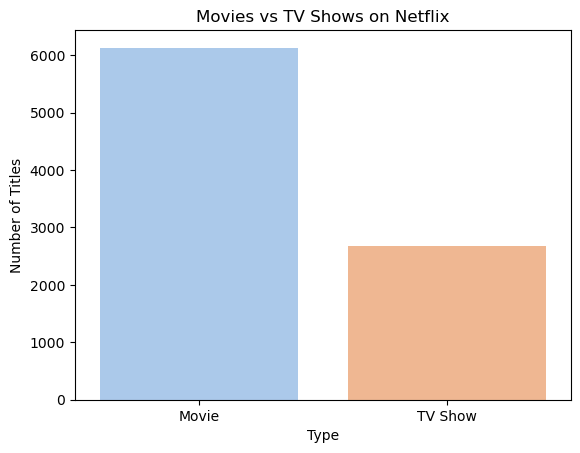

In [101]:
type_counts = df["type"].value_counts().reset_index()
type_counts.columns = ["Type", "Count"]

sns.barplot(x="Type", y="Count", data=type_counts, palette="pastel")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.show()

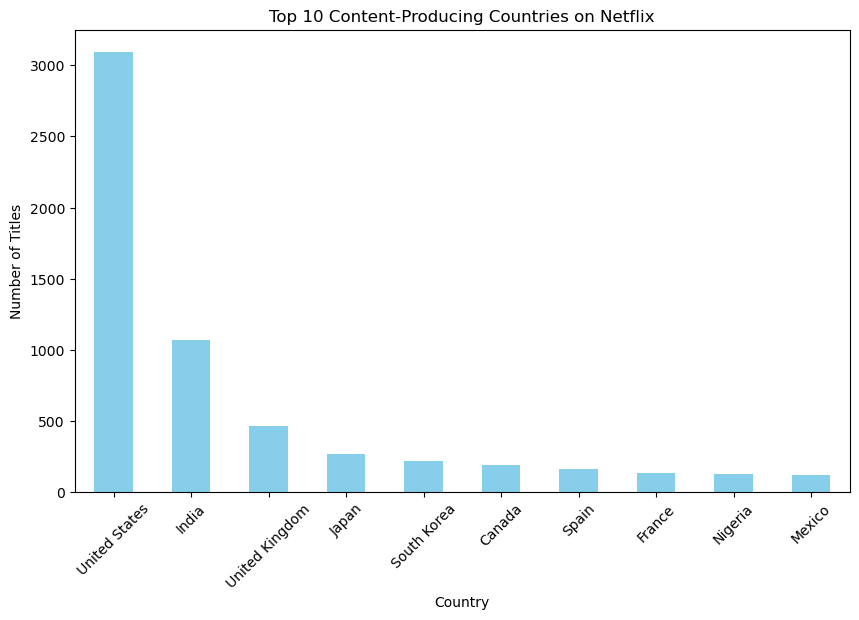

In [127]:
# Count titles by country
country_counts = df['country'].value_counts().head(10) 

# Bar plot
country_counts.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title("Top 10 Content-Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

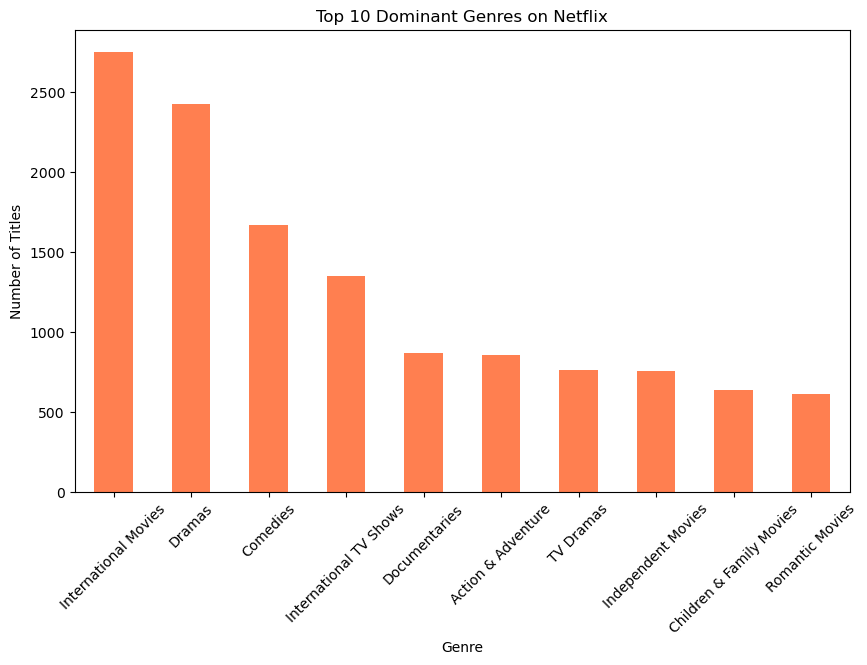

In [128]:
# Split genres into individual entries
genre_counts = (
    df['listed_in']
    .str.split(',')                
    .explode()                     # expand into separate rows
    .str.strip()                   # remove extra spaces
    .value_counts()                # count frequency
)

top_genres = genre_counts.head(10)

# Bar plot
top_genres.plot(kind='bar', figsize=(10,6), color='coral')
plt.title("Top 10 Dominant Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

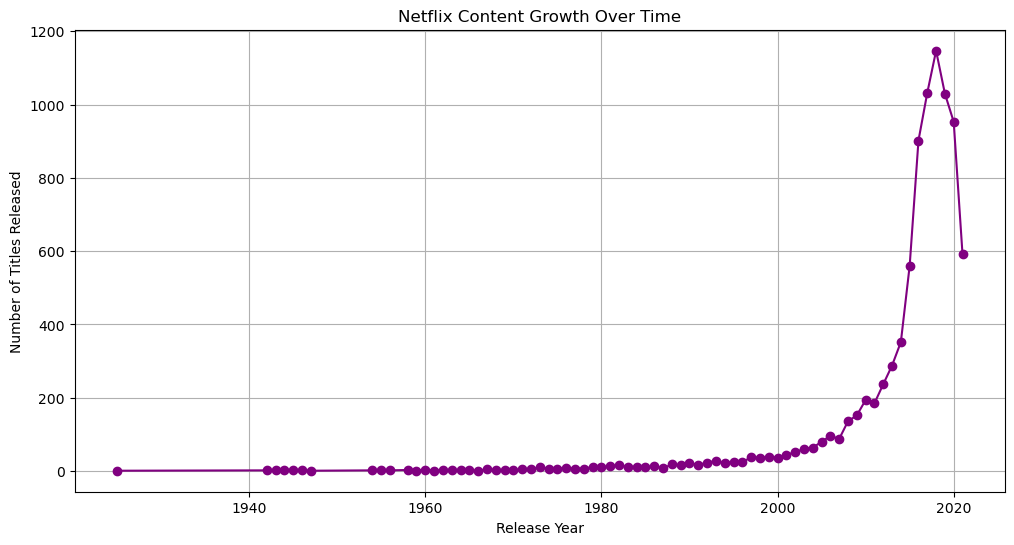

In [130]:
# Count titles by release year
year_counts = df['release_year'].value_counts().sort_index()

# Line plot
year_counts.plot(kind='line', figsize=(12,6), marker='o', color='purple')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles Released")
plt.grid(True)
plt.show()

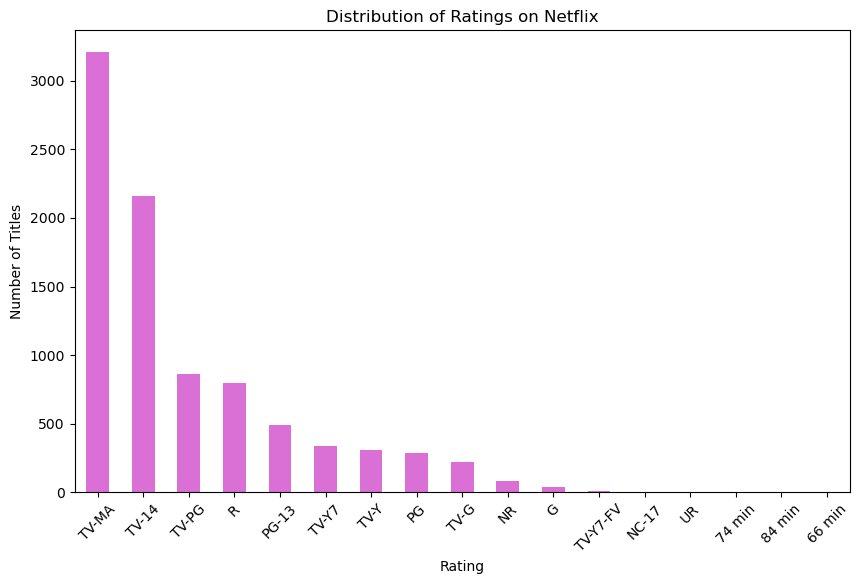

In [131]:
# Count ratings
rating_counts = df['rating'].value_counts()

# Bar plot
rating_counts.plot(kind='bar', figsize=(10,6), color='orchid')
plt.title("Distribution of Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [132]:
df.to_csv("Clean_Netflix_Dataset.csv")